# Remove Printed Text — Keep Handwriting Only

Each attempt is fully self-contained. Run any attempt independently without running the others.

| # | Method | Key idea | Status |
|---|--------|----------|--------|
| 1 | Max-map + fixed threshold | Pixel-wise max across 300 samples; erase always-dark positions | Failed — scan misalignment prevented mask from forming |
| 2 | HebHTR Docker | Crop word blobs → HebHTR classifies handwritten vs printed | Failed — HebHTR reads printed Hebrew too, kept everything |
| 3 | Max-map + adaptive binarization + CC cleanup | Binarize before stacking; erase always-dark positions; drop small blobs | Failed — mask still empty due to misalignment |
| 4 | Line-aligned max-map | Vertically align images by first horizontal line before stacking | Failed — mask still mostly empty |
| 5 | Tesseract per image | Run Tesseract on each image; erase high-confidence word boxes | Partial — misses some printed text, occasionally erases handwriting |
| 12 | HSV color separation | Keep only colored (non-black) ink via saturation threshold; restore ruled lines | Good for colored handwriting — black handwriting not preserved |


---
## Attempt 1 — Max-map + Fixed Threshold

Take the **pixel-wise maximum** across a sample of images.
- Printed pixels are dark in **every** image → max stays dark
- Handwriting pixels are dark in only **some** images → max becomes white

Keep pixels that are dark in this image **but bright in the max-map** = handwriting.

In [ ]:
import os, cv2, random, numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
A1_INPUT_FOLDER       = "dataPrinted"
A1_OUTPUT_FOLDER      = "handwritenOnly"
A1_SAMPLE_SIZE        = 300
A1_INK_THRESHOLD      = 180   # pixel is 'ink' if gray < this
A1_PRINTED_THRESHOLD  = 180   # position is 'printed' if max_map < this
A1_SUPPORTED_EXTS     = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

os.makedirs(A1_OUTPUT_FOLDER, exist_ok=True)
print(f"Output folder ready: {A1_OUTPUT_FOLDER}")

In [ ]:
a1_image_files = [
    f for f in os.listdir(A1_INPUT_FOLDER)
    if Path(f).suffix.lower() in A1_SUPPORTED_EXTS
]
print(f"Found {len(a1_image_files)} images")

In [ ]:
a1_sample = random.sample(a1_image_files, min(A1_SAMPLE_SIZE, len(a1_image_files)))
a1_stack, a1_ref_shape = [], None

for fname in tqdm(a1_sample, desc="Building max-map"):
    img = cv2.imread(os.path.join(A1_INPUT_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    if a1_ref_shape is None: a1_ref_shape = img.shape
    if img.shape != a1_ref_shape:
        img = cv2.resize(img, (a1_ref_shape[1], a1_ref_shape[0]), interpolation=cv2.INTER_AREA)
    a1_stack.append(img.astype(np.float32))

a1_max_map = np.max(np.stack(a1_stack, axis=0), axis=0).astype(np.uint8)
print(f"Max-map built. Always-dark pixels: {(a1_max_map < A1_PRINTED_THRESHOLD).mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(a1_max_map, cmap="gray"); axes[0].set_title("Max map"); axes[0].axis("off")
axes[1].imshow((a1_max_map < A1_PRINTED_THRESHOLD).astype(np.uint8)*255, cmap="gray")
axes[1].set_title("Printed-content mask"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
def a1_detect_lines(img_gray, min_length=80):
    _, binary = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    return cv2.dilate(cv2.erode(binary, k), k) > 0

def a1_process(img_bgr, max_map):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    m = max_map if max_map.shape == img_gray.shape else \
        cv2.resize(max_map, (img_gray.shape[1], img_gray.shape[0]), interpolation=cv2.INTER_LINEAR)

    handwriting_mask = (img_gray < A1_INK_THRESHOLD) & (m >= A1_PRINTED_THRESHOLD)
    combined = handwriting_mask | a1_detect_lines(img_gray)

    result = np.full_like(img_bgr, 255)
    result[combined] = img_bgr[combined]
    return result

In [ ]:
a1_preview = random.sample(a1_image_files, min(10, len(a1_image_files)))
fig, axes = plt.subplots(10, 2, figsize=(16, 40))
for i, fname in enumerate(a1_preview):
    img = cv2.imread(os.path.join(A1_INPUT_FOLDER, fname))
    if img is None: continue
    result = a1_process(img, a1_max_map)
    axes[i][0].imshow(cv2.cvtColor(img,    cv2.COLOR_BGR2RGB)); axes[i][0].set_title(f"Before — {fname}", fontsize=8); axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[i][1].set_title("After",              fontsize=8); axes[i][1].axis("off")
plt.suptitle("Attempt 1 Preview", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

In [ ]:
a1_errors = []
for fname in tqdm(a1_image_files, desc="Attempt 1"):
    img = cv2.imread(os.path.join(A1_INPUT_FOLDER, fname))
    if img is None: a1_errors.append(fname); continue
    cv2.imwrite(os.path.join(A1_OUTPUT_FOLDER, fname), a1_process(img, a1_max_map))
print(f"Done. {len(a1_image_files)-len(a1_errors)}/{len(a1_image_files)} saved to '{A1_OUTPUT_FOLDER}'.")

---
## Attempt 2 — HebHTR Docker

Detect all text blobs via morphological grouping, send each crop to the HebHTR Docker container.
If HebHTR returns text → keep (handwritten). If empty/error → discard (printed).

> Build image first: `docker build -f dockerFile -t hebhtr .`
>
> **Note:** HebHTR recognises both printed and handwritten Hebrew, so this may not filter correctly.

In [ ]:
import os, cv2, random, json, shutil, subprocess, numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
A2_INPUT_FOLDER   = "dataPrinted"
A2_OUTPUT_FOLDER  = "handwritenOnly"
A2_DOCKER_IMAGE   = "hebhtr"
A2_CROPS_TMP      = "crops_tmp"
A2_BOX_PADDING    = 5
A2_MIN_BOX_AREA   = 300
A2_DILATE_W       = 25
A2_DILATE_H       = 5
A2_SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

os.makedirs(A2_OUTPUT_FOLDER, exist_ok=True)
print(f"Output folder ready: {A2_OUTPUT_FOLDER}")

In [ ]:
a2_image_files = [
    f for f in os.listdir(A2_INPUT_FOLDER)
    if Path(f).suffix.lower() in A2_SUPPORTED_EXTS
]
print(f"Found {len(a2_image_files)} images")

In [ ]:
def a2_detect_lines(img_gray, min_length=80):
    _, binary = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    return cv2.dilate(cv2.erode(binary, k), k) > 0

def a2_detect_boxes(img_gray):
    H, W = img_gray.shape
    _, binary = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (A2_DILATE_W, A2_DILATE_H))
    dilated = cv2.dilate(binary, k)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h < A2_MIN_BOX_AREA: continue
        boxes.append((max(0,x-A2_BOX_PADDING), max(0,y-A2_BOX_PADDING),
                      min(W,x+w+A2_BOX_PADDING)-max(0,x-A2_BOX_PADDING),
                      min(H,y+h+A2_BOX_PADDING)-max(0,y-A2_BOX_PADDING)))
    return boxes

def a2_classify(img_gray, boxes):
    shutil.rmtree(A2_CROPS_TMP, ignore_errors=True)
    os.makedirs(A2_CROPS_TMP)
    names = []
    for i, (x, y, w, h) in enumerate(boxes):
        fname = f"crop_{i:04d}.png"
        cv2.imwrite(os.path.join(A2_CROPS_TMP, fname), img_gray[y:y+h, x:x+w])
        names.append(fname)
    if not names: return set()
    proc = subprocess.run(
        ["docker", "run", "--rm",
         "-v", f"{os.path.abspath(A2_CROPS_TMP)}:/crops",
         "-v", f"{os.path.abspath('hebhtr_worker.py')}:/app/worker.py",
         A2_DOCKER_IMAGE, "python", "/app/worker.py", "/crops"],
        capture_output=True, text=True, encoding="utf-8", timeout=180
    )
    if proc.returncode != 0: print(proc.stderr[:300]); return set()
    try: preds = json.loads(proc.stdout)
    except: return set()
    return {i for i, n in enumerate(names)
            if preds.get(n,"") and not preds[n].startswith(("ERROR","MODEL_LOAD"))}

def a2_process(img_bgr):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    boxes = a2_detect_boxes(img_gray)
    hw_idx = a2_classify(img_gray, boxes)
    result = np.full_like(img_bgr, 255)
    for i in hw_idx:
        x, y, w, h = boxes[i]
        result[y:y+h, x:x+w] = img_bgr[y:y+h, x:x+w]
    result[a2_detect_lines(img_gray)] = img_bgr[a2_detect_lines(img_gray)]
    return result, boxes, hw_idx

In [ ]:
a2_preview = random.sample(a2_image_files, min(10, len(a2_image_files)))
fig, axes = plt.subplots(10, 3, figsize=(18, 40))
for i, fname in enumerate(a2_preview):
    img = cv2.imread(os.path.join(A2_INPUT_FOLDER, fname))
    if img is None: continue
    result, boxes, hw_idx = a2_process(img)
    img_boxes = img.copy()
    for j, (x,y,w,h) in enumerate(boxes):
        cv2.rectangle(img_boxes,(x,y),(x+w,y+h),(0,200,0) if j in hw_idx else (0,0,200),2)
    axes[i][0].imshow(cv2.cvtColor(img,       cv2.COLOR_BGR2RGB)); axes[i][0].set_title(f"Before — {fname}", fontsize=8); axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)); axes[i][1].set_title(f"Boxes (green=keep, red=drop) [{len(hw_idx)}/{len(boxes)}]", fontsize=8); axes[i][1].axis("off")
    axes[i][2].imshow(cv2.cvtColor(result,    cv2.COLOR_BGR2RGB)); axes[i][2].set_title("After", fontsize=8); axes[i][2].axis("off")
plt.suptitle("Attempt 2 Preview — HebHTR", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

In [ ]:
a2_errors = []
for fname in tqdm(a2_image_files, desc="Attempt 2"):
    img = cv2.imread(os.path.join(A2_INPUT_FOLDER, fname))
    if img is None: a2_errors.append(fname); continue
    try:
        result, _, _ = a2_process(img)
        cv2.imwrite(os.path.join(A2_OUTPUT_FOLDER, fname), result)
    except Exception as e:
        a2_errors.append(fname); print(f"  {fname}: {e}")
print(f"Done. {len(a2_image_files)-len(a2_errors)}/{len(a2_image_files)} saved to '{A2_OUTPUT_FOLDER}'.")

---
## Attempt 3 — Max-map + Adaptive Binarization + Connected Component Cleanup

1. **Max-map** — identifies always-dark (printed) pixel positions across the population
2. **Adaptive binarization** — better ink detection than fixed threshold (handles uneven scan lighting)
3. **Connected component cleanup** — drops small residual blobs (printed fragments that leaked through)
4. **Horizontal lines** — always restored

In [7]:
import os, cv2, random, numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [8]:
A3_INPUT_FOLDER    = "dataPrinted"
A3_OUTPUT_FOLDER   = "handwritenOnly"
A3_SAMPLE_SIZE     = 300
A3_PRINT_DILATE    = 1     # expand printed mask by this many px to catch anti-aliased edges (keep small!)
A3_SUPPORTED_EXTS  = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

os.makedirs(A3_OUTPUT_FOLDER, exist_ok=True)
print(f"Output folder ready: {A3_OUTPUT_FOLDER}")

Output folder ready: handwritenOnly


In [9]:
a3_image_files = [
    f for f in os.listdir(A3_INPUT_FOLDER)
    if Path(f).suffix.lower() in A3_SUPPORTED_EXTS
]
print(f"Found {len(a3_image_files)} images")

Found 28203 images


Grouping by size: 100%|██████████| 28203/28203 [08:23<00:00, 56.04it/s]


Form groups found:
  (146, 669) → 6707 images
  (350, 604) → 6452 images
  (150, 1617) → 4937 images
  (108, 1601) → 3902 images
  (228, 1476) → 1282 images
  (278, 1384) → 1238 images
  (400, 1660) → 634 images
  (400, 1633) → 241 images
  (400, 1636) → 222 images
  (400, 1647) → 212 images
  (400, 1653) → 205 images
  (150, 604) → 205 images
  (400, 1644) → 200 images
  (106, 1617) → 174 images
  (400, 1642) → 150 images
  (400, 1655) → 130 images
  (400, 1630) → 129 images
  (240, 1384) → 108 images
  (400, 1639) → 106 images
  (400, 1658) → 89 images
  (400, 1650) → 88 images
  (400, 1622) → 62 images
  (188, 395) → 61 images
  (150, 430) → 61 images
  (120, 1115) → 48 images
  (400, 1619) → 40 images
  (100, 1065) → 40 images
  (400, 1614) → 37 images
  (400, 1628) → 35 images
  (400, 1625) → 30 images
  (400, 1617) → 24 images
  (146, 665) → 23 images
  (360, 1644) → 20 images
  (400, 1611) → 20 images
  (150, 1616) → 17 images
  (360, 1647) → 17 images
  (150, 1605) → 16 images


Building max-map: 100%|██████████| 300/300 [00:00<00:00, 443.03it/s]


Printed-content pixels: 0.00%
⚠️  WARNING: mask is nearly empty — images may still be misaligned or all different forms


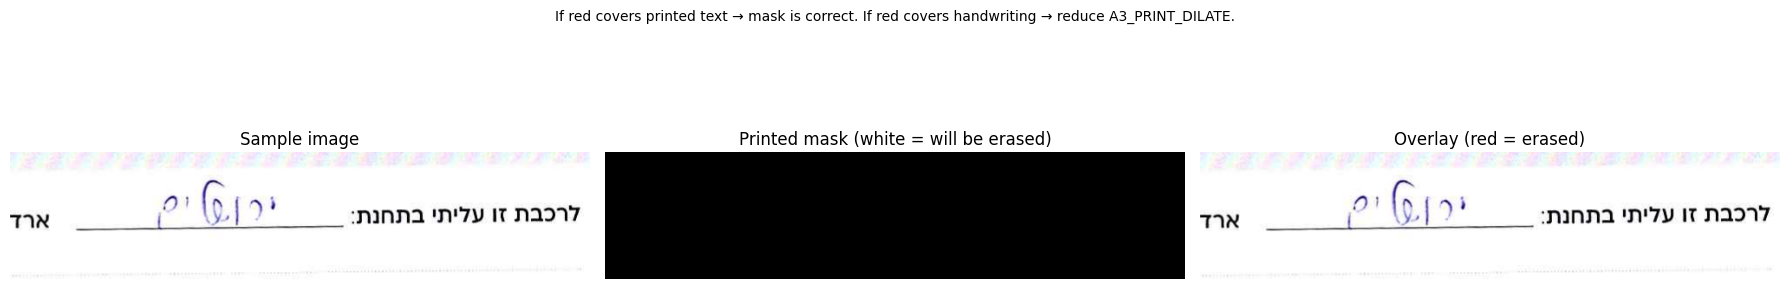

In [10]:
# ── Group images by resolution so we only stack the same form type ─────────────
from collections import defaultdict

size_groups = defaultdict(list)
for fname in tqdm(a3_image_files, desc="Grouping by size"):
    img = cv2.imread(os.path.join(A3_INPUT_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        size_groups[img.shape].append(fname)

print("Form groups found:")
for shape, files in sorted(size_groups.items(), key=lambda x: -len(x[1])):
    print(f"  {shape} → {len(files)} images")

# Use the largest group (most common form type)
a3_group_files = max(size_groups.values(), key=len)
print(f"\nUsing group with {len(a3_group_files)} images for max-map")

# ── Build binarized max-map from this group ────────────────────────────────────
a3_sample = random.sample(a3_group_files, min(A3_SAMPLE_SIZE, len(a3_group_files)))
a3_stack, a3_ref_shape = [], None

for fname in tqdm(a3_sample, desc="Building max-map"):
    img = cv2.imread(os.path.join(A3_INPUT_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    if a3_ref_shape is None: a3_ref_shape = img.shape
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    a3_stack.append(binary.astype(np.float32))

a3_max_map = np.max(np.stack(a3_stack, axis=0), axis=0).astype(np.uint8)

a3_printed_mask = (a3_max_map < 128).astype(np.uint8) * 255
if A3_PRINT_DILATE > 0:
    dk = np.ones((A3_PRINT_DILATE, A3_PRINT_DILATE), np.uint8)
    a3_printed_mask = cv2.dilate(a3_printed_mask, dk)

pct = (a3_printed_mask > 0).mean() * 100
print(f"Printed-content pixels: {pct:.2f}%")
if pct < 0.1:
    print("⚠️  WARNING: mask is nearly empty — images may still be misaligned or all different forms")

# ── Debug: overlay mask in red on one sample image ────────────────────────────
debug_img = cv2.imread(os.path.join(A3_INPUT_FOLDER, a3_sample[0]))
debug_vis = debug_img.copy()
debug_vis[a3_printed_mask > 0] = [0, 0, 255]   # red = will be erased

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Sample image"); axes[0].axis("off")
axes[1].imshow(a3_printed_mask, cmap="gray");                axes[1].set_title("Printed mask (white = will be erased)"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay (red = erased)"); axes[2].axis("off")
plt.suptitle("If red covers printed text → mask is correct. If red covers handwriting → reduce A3_PRINT_DILATE.", fontsize=10)
plt.tight_layout(); plt.show()

In [5]:
def a3_detect_lines(img_gray, min_length=80):
    _, binary = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    return cv2.dilate(cv2.erode(binary, k), k) > 0

def a3_process(img_bgr, printed_mask):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Resize mask to this image if needed
    pm = printed_mask if printed_mask.shape == img_gray.shape else \
        cv2.resize(printed_mask, (img_gray.shape[1], img_gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    # White out every pixel that belongs to the printed form
    result = img_bgr.copy()
    result[pm > 0] = 255

    # Restore horizontal lines from the original image
    result[a3_detect_lines(img_gray)] = img_bgr[a3_detect_lines(img_gray)]

    return result

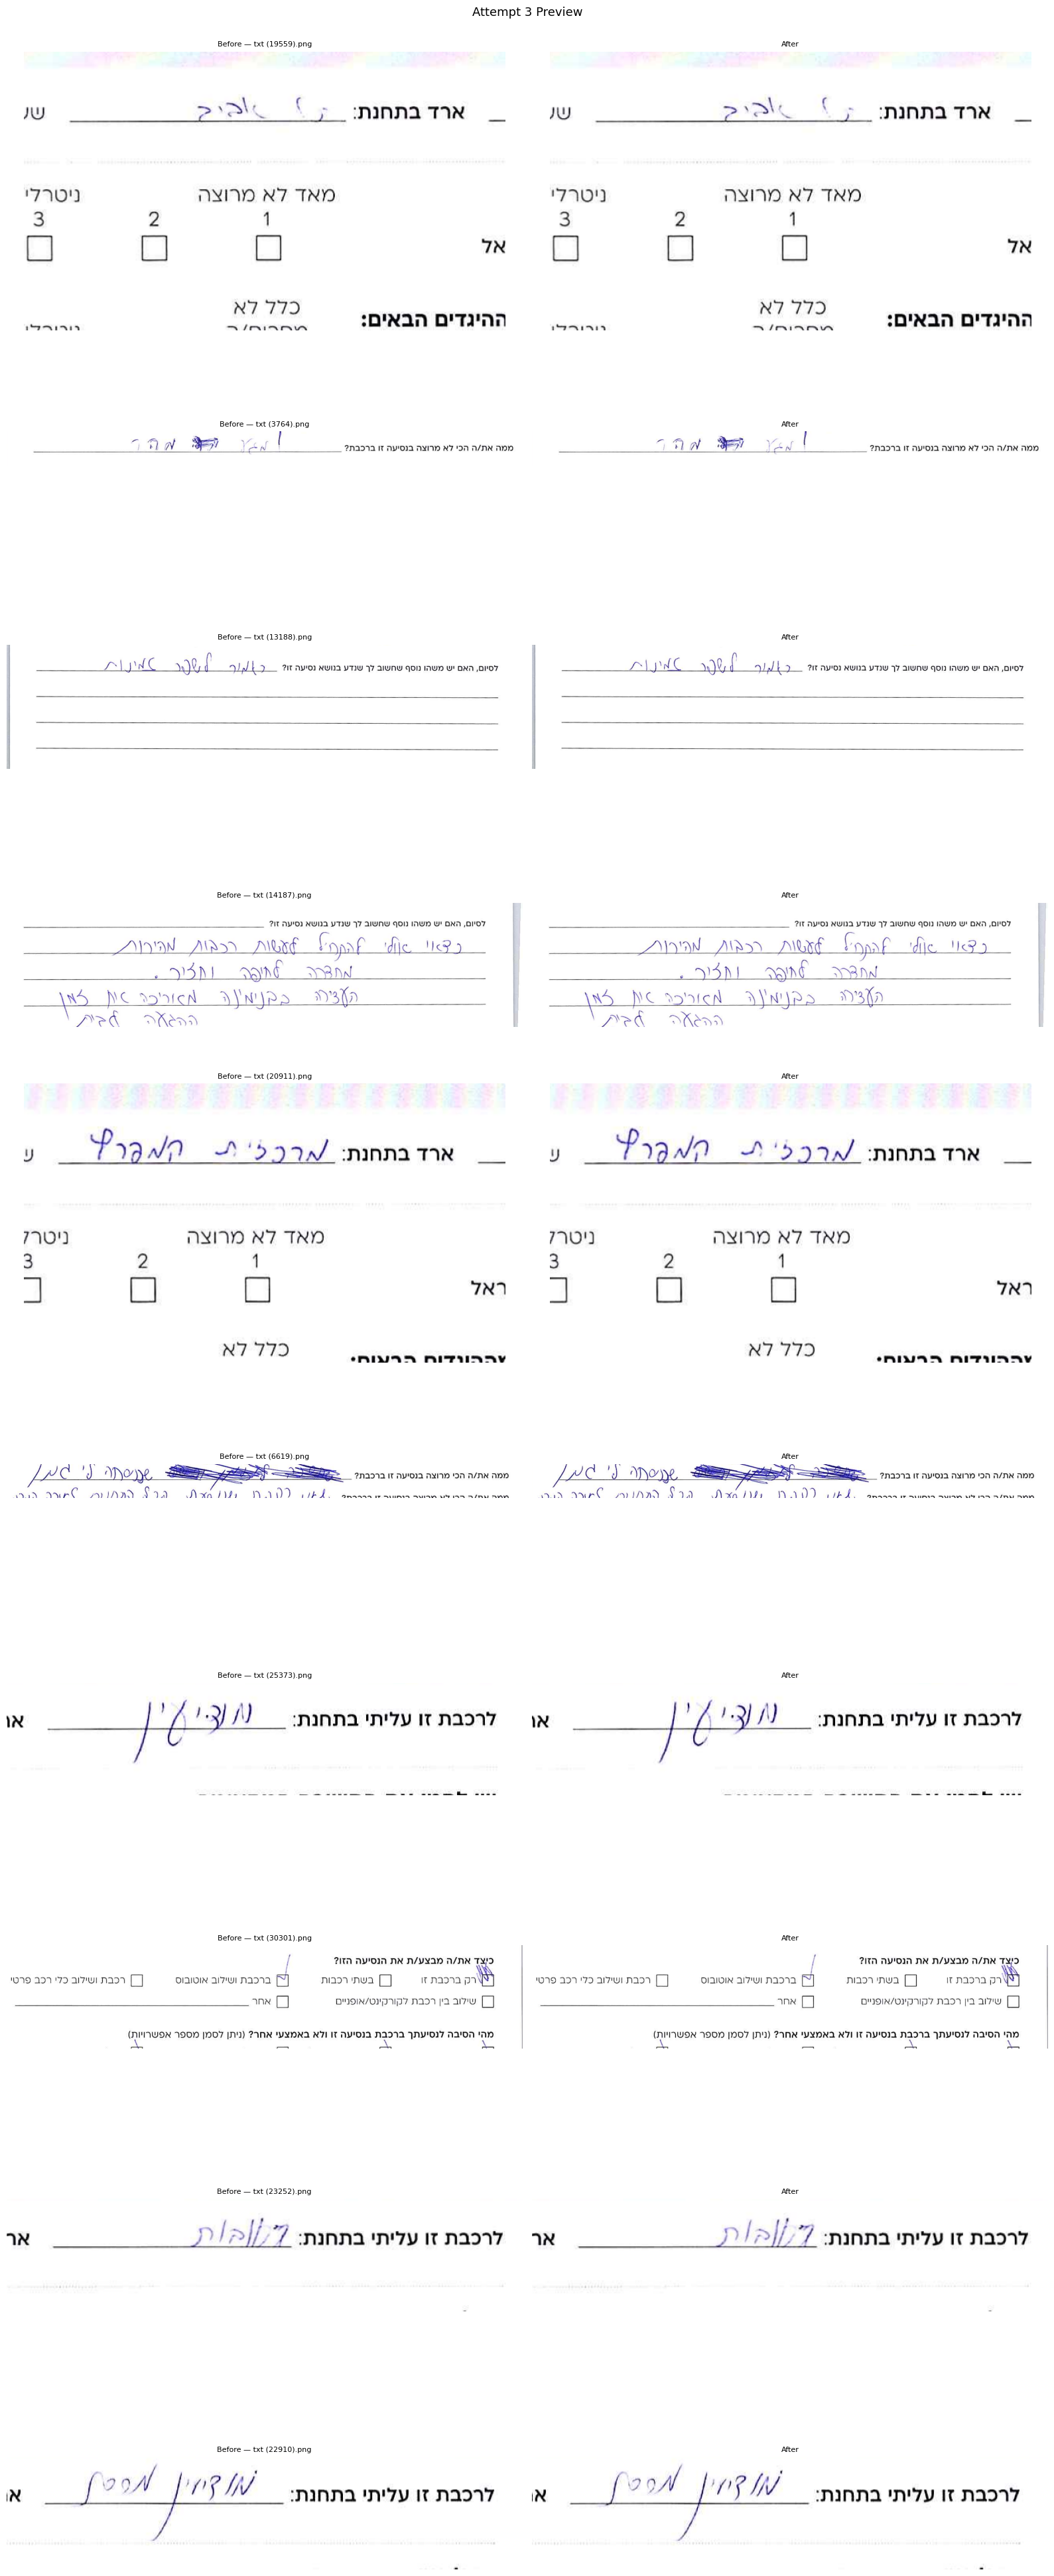

In [6]:
a3_preview = random.sample(a3_image_files, min(10, len(a3_image_files)))
fig, axes = plt.subplots(10, 2, figsize=(16, 40))
for i, fname in enumerate(a3_preview):
    img = cv2.imread(os.path.join(A3_INPUT_FOLDER, fname))
    if img is None: continue
    result = a3_process(img, a3_printed_mask)
    axes[i][0].imshow(cv2.cvtColor(img,    cv2.COLOR_BGR2RGB)); axes[i][0].set_title(f"Before — {fname}", fontsize=8); axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[i][1].set_title("After",              fontsize=8); axes[i][1].axis("off")
plt.suptitle("Attempt 3 Preview", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

In [ ]:
a3_errors = []
for fname in tqdm(a3_image_files, desc="Attempt 3"):
    img = cv2.imread(os.path.join(A3_INPUT_FOLDER, fname))
    if img is None: a3_errors.append(fname); continue
    cv2.imwrite(os.path.join(A3_OUTPUT_FOLDER, fname), a3_process(img, a3_printed_mask))
print(f"Done. {len(a3_image_files)-len(a3_errors)}/{len(a3_image_files)} saved to '{A3_OUTPUT_FOLDER}'.")

---
## Attempt 4 — Line-aligned Max-map

**Root cause of all previous failures:** even a 2-3px scanner offset means printed text pixels are never at the *exact* same position across all images, so the max-map stays white everywhere.

**Fix:** use the horizontal lines as alignment anchors.
1. Detect horizontal lines in each sample image → get their Y-position
2. Vertically shift each binarized image so its first line aligns with the reference
3. Build max-map from these aligned images → printed text now stacks consistently
4. When processing each image, shift the mask to match *that* image's line position
5. White out the printed mask → restore the actual lines from the original image

In [1]:
import os, cv2, random, numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
A4_INPUT_FOLDER   = "dataPrinted"
A4_OUTPUT_FOLDER  = "handwritenOnly"
A4_SAMPLE_SIZE    = 300
A4_LINE_MIN_LEN   = 100   # minimum px length to count as a printed horizontal line
A4_SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

os.makedirs(A4_OUTPUT_FOLDER, exist_ok=True)

a4_image_files = [f for f in os.listdir(A4_INPUT_FOLDER)
                  if Path(f).suffix.lower() in A4_SUPPORTED_EXTS]
print(f"Found {len(a4_image_files)} images")

Found 28203 images


Reference first-line Y = 63  (shape (146, 669))


Building aligned max-map: 100%|██████████| 300/300 [00:02<00:00, 116.15it/s]


Printed-content pixels after alignment: 0.00%


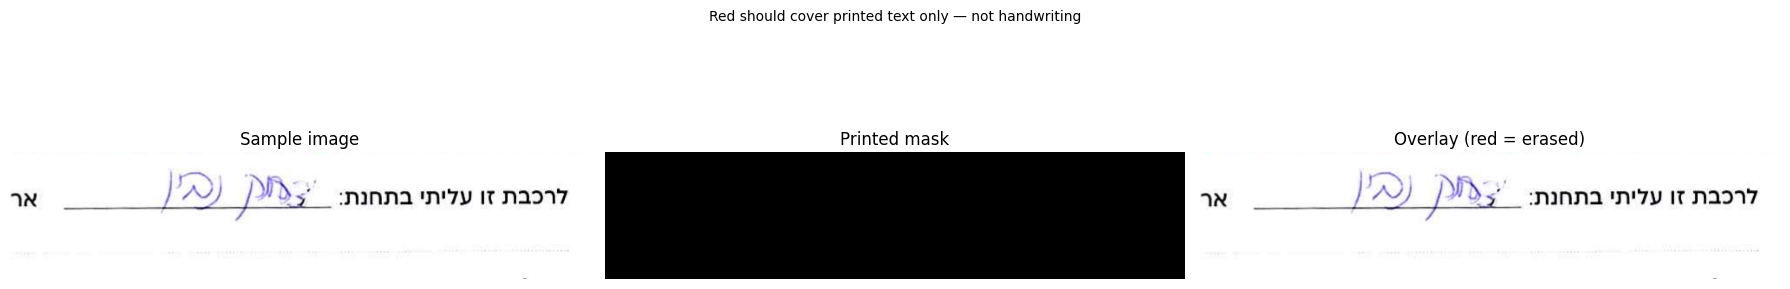

In [3]:
def a4_get_first_line_y(img_gray, min_length=A4_LINE_MIN_LEN):
    """Return Y-coordinate of the centre of the first detected horizontal line, or None."""
    _, binary = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    line_mask = cv2.erode(binary, k)
    rows_with_line = np.where(line_mask.max(axis=1) > 0)[0]
    return int(rows_with_line.mean()) if len(rows_with_line) > 0 else None

def a4_detect_lines(img_gray, min_length=A4_LINE_MIN_LEN):
    """Boolean mask of all horizontal line pixels."""
    _, binary = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    return cv2.dilate(cv2.erode(binary, k), k) > 0

def a4_shift(img, dy, fill=255):
    """Shift image vertically by dy pixels (positive = down)."""
    M = np.float32([[1, 0, 0], [0, 1, dy]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                          borderMode=cv2.BORDER_CONSTANT, borderValue=fill)

# ── Build line-aligned max-map ─────────────────────────────────────────────────
a4_sample = random.sample(a4_image_files, min(A4_SAMPLE_SIZE, len(a4_image_files)))

# Determine reference Y from first usable image
a4_ref_y = None
for fname in a4_sample:
    img = cv2.imread(os.path.join(A4_INPUT_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    y = a4_get_first_line_y(img)
    if y is not None:
        a4_ref_y   = y
        a4_ref_shape = img.shape
        break

print(f"Reference first-line Y = {a4_ref_y}  (shape {a4_ref_shape})")

a4_stack = []
for fname in tqdm(a4_sample, desc="Building aligned max-map"):
    img = cv2.imread(os.path.join(A4_INPUT_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # Resize to reference shape
    if img.shape != a4_ref_shape:
        img = cv2.resize(img, (a4_ref_shape[1], a4_ref_shape[0]), interpolation=cv2.INTER_AREA)

    # Binarize
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Align: shift so this image's first line sits at ref_y
    y = a4_get_first_line_y(img)
    if y is not None and y != a4_ref_y:
        binary = a4_shift(binary, a4_ref_y - y, fill=255)

    a4_stack.append(binary.astype(np.float32))

a4_max_map      = np.max(np.stack(a4_stack, axis=0), axis=0).astype(np.uint8)
a4_printed_mask = (a4_max_map < 128).astype(np.uint8) * 255

pct = (a4_printed_mask > 0).mean() * 100
print(f"Printed-content pixels after alignment: {pct:.2f}%")

# Debug overlay on the reference image
ref_bgr   = cv2.imread(os.path.join(A4_INPUT_FOLDER, a4_sample[0]))
debug_vis = ref_bgr.copy()
debug_vis[a4_printed_mask > 0] = [0, 0, 255]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(cv2.cvtColor(ref_bgr,   cv2.COLOR_BGR2RGB)); axes[0].set_title("Sample image");          axes[0].axis("off")
axes[1].imshow(a4_printed_mask, cmap="gray");               axes[1].set_title("Printed mask");           axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB)); axes[2].set_title("Overlay (red = erased)"); axes[2].axis("off")
plt.suptitle("Red should cover printed text only — not handwriting", fontsize=10)
plt.tight_layout(); plt.show()

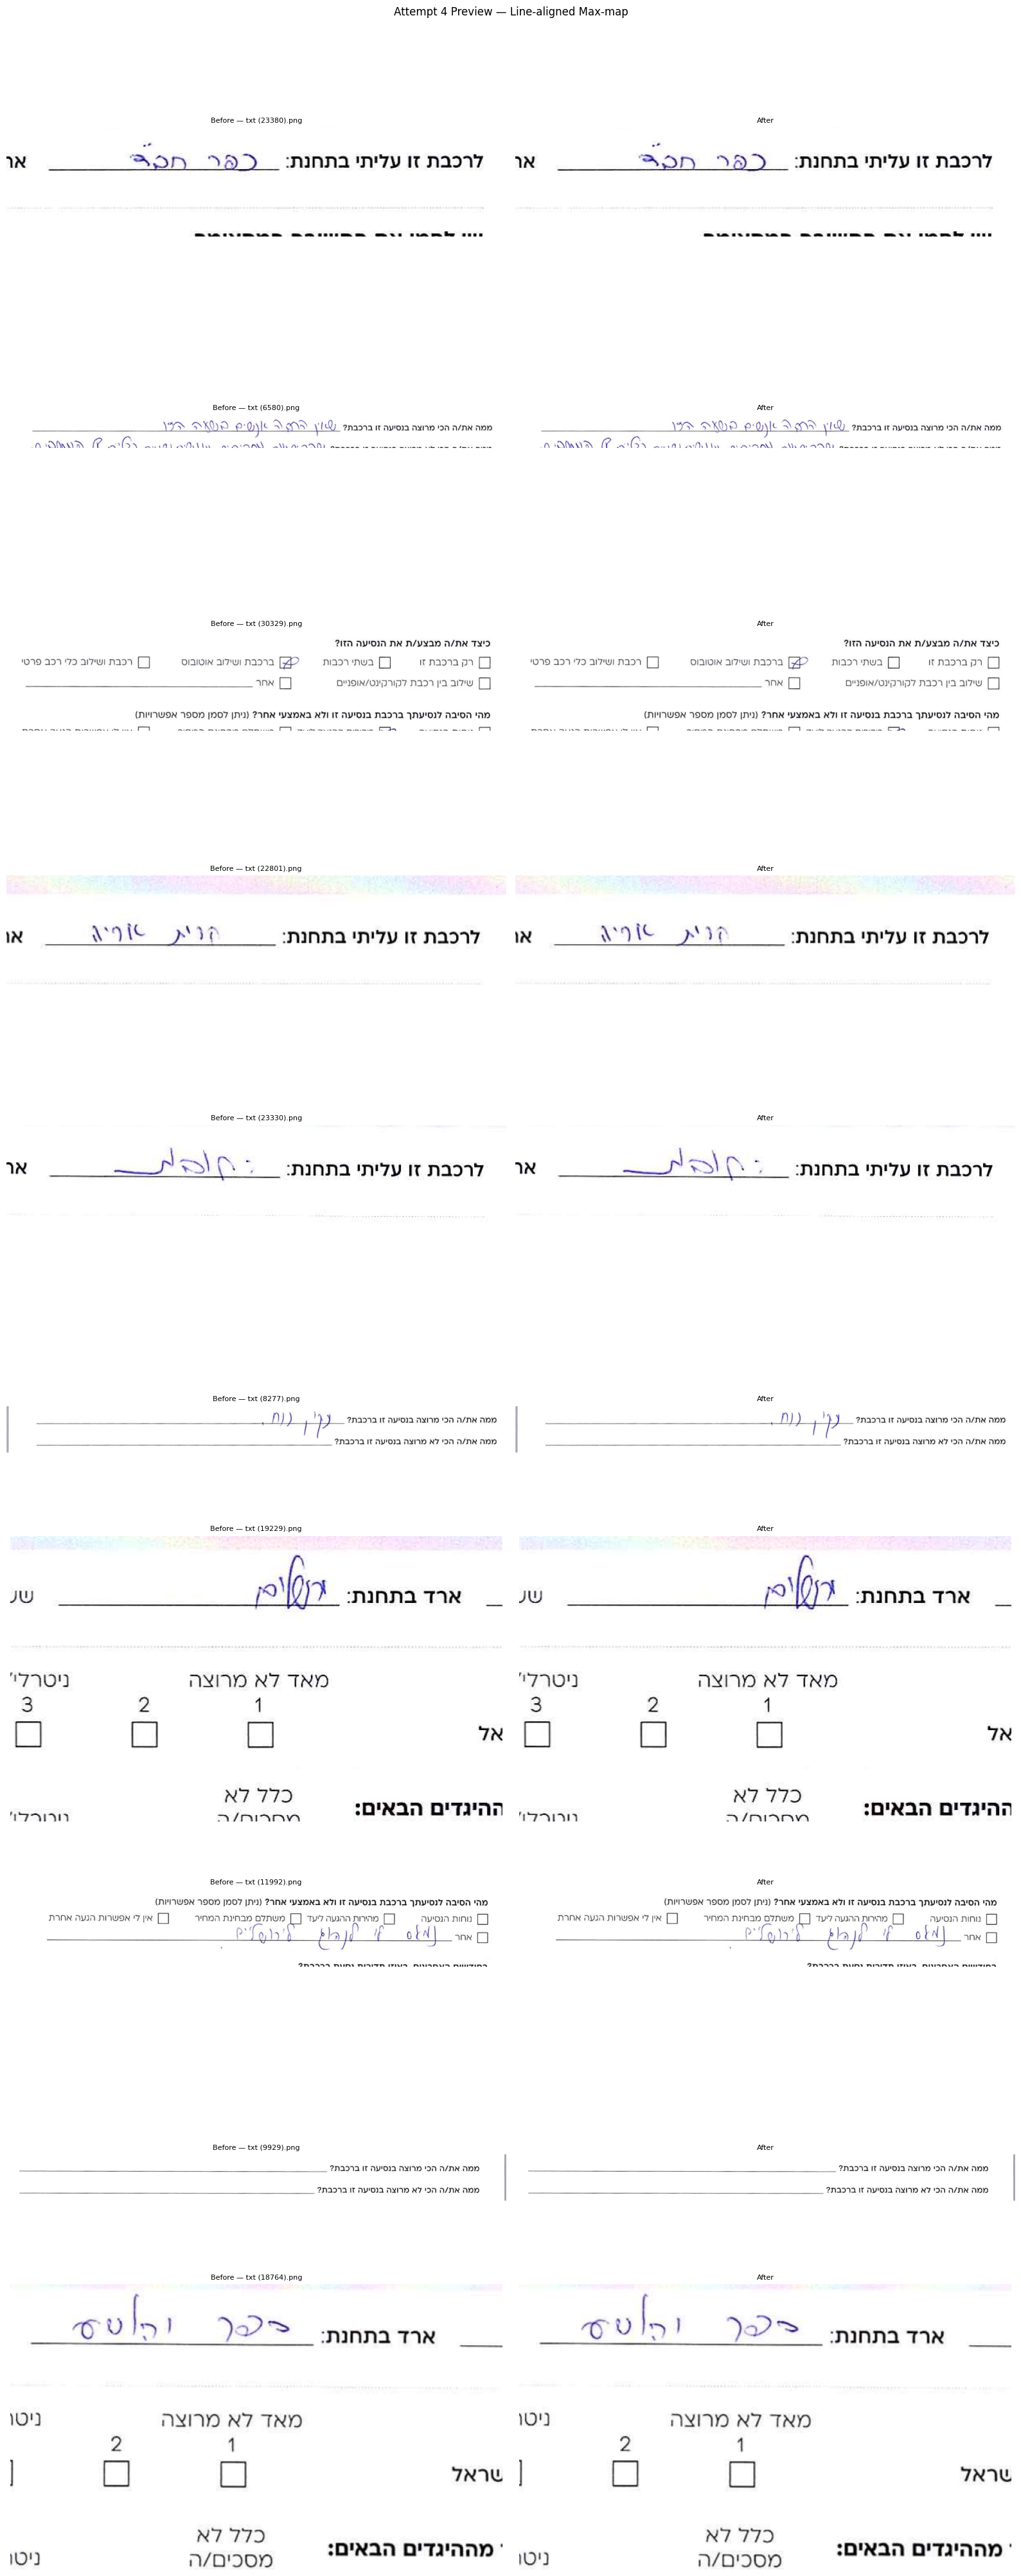

In [4]:
def a4_process(img_bgr, printed_mask, ref_y):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Shift the mask to align with THIS image's line position
    pm = printed_mask.copy()
    y  = a4_get_first_line_y(img_gray)
    if y is not None and y != ref_y:
        pm = a4_shift(pm, y - ref_y, fill=0)   # fill=0 so shifted area doesn't erase

    if pm.shape != img_gray.shape:
        pm = cv2.resize(pm, (img_gray.shape[1], img_gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    # White out printed content
    result = img_bgr.copy()
    result[pm > 0] = 255

    # Restore horizontal lines from the original
    result[a4_detect_lines(img_gray)] = img_bgr[a4_detect_lines(img_gray)]

    return result


# ── Preview ────────────────────────────────────────────────────────────────────
a4_preview = random.sample(a4_image_files, min(10, len(a4_image_files)))
fig, axes  = plt.subplots(10, 2, figsize=(16, 40))

for i, fname in enumerate(a4_preview):
    img    = cv2.imread(os.path.join(A4_INPUT_FOLDER, fname))
    if img is None: continue
    result = a4_process(img, a4_printed_mask, a4_ref_y)
    axes[i][0].imshow(cv2.cvtColor(img,    cv2.COLOR_BGR2RGB)); axes[i][0].set_title(f"Before — {fname}", fontsize=8); axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[i][1].set_title("After",              fontsize=8); axes[i][1].axis("off")

plt.suptitle("Attempt 4 Preview — Line-aligned Max-map", fontsize=12, y=1.001)
plt.tight_layout(); plt.show()

In [ ]:
a4_errors = []
for fname in tqdm(a4_image_files, desc="Attempt 4"):
    img = cv2.imread(os.path.join(A4_INPUT_FOLDER, fname))
    if img is None: a4_errors.append(fname); continue
    cv2.imwrite(os.path.join(A4_OUTPUT_FOLDER, fname), a4_process(img, a4_printed_mask, a4_ref_y))
print(f"Done. {len(a4_image_files)-len(a4_errors)}/{len(a4_image_files)} saved to '{A4_OUTPUT_FOLDER}'.")

---
## Attempt 5 — Tesseract OCR printed-text detection

**Why this is different:** All previous attempts tried to find printed pixels statistically (cross-image max-map). That fails due to scan misalignment.

**New approach:** Use Tesseract — an OCR engine trained *specifically on machine-printed fonts*.
- Tesseract on **printed Hebrew text** → high confidence, clear bounding boxes
- Tesseract on **handwriting** → near-zero confidence, no reliable boxes

So: white out every word box where Tesseract confidence > threshold. Keep everything else (handwriting). Restore horizontal lines.

**Setup (run once):**
```
pip install pytesseract
# Windows: install Tesseract from https://github.com/UB-Mannheim/tesseract/wiki
# Then install Hebrew language data: download heb.traineddata → Tesseract tessdata folder
```

In [10]:
import os, cv2, random, numpy as np, pytesseract
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# If Tesseract is not on PATH, set it explicitly:
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

print("Tesseract version:", pytesseract.get_tesseract_version())

Tesseract version: 5.5.0.20241111


In [11]:
A5_INPUT_FOLDER   = "dataPrinted"
A5_OUTPUT_FOLDER  = "handwritenOnly"
A5_LANG           = "heb"      # Hebrew; use "heb+eng" if form also has English
A5_CONF_THRESHOLD = 50         # word boxes with confidence > this are printed → erased
                               # lower = more aggressive removal; raise if handwriting is erased
A5_LINE_MIN_LEN   = 100
A5_SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

os.makedirs(A5_OUTPUT_FOLDER, exist_ok=True)

a5_image_files = [f for f in os.listdir(A5_INPUT_FOLDER)
                  if Path(f).suffix.lower() in A5_SUPPORTED_EXTS]
print(f"Found {len(a5_image_files)} images")

Found 28203 images


In [12]:
def a5_detect_lines(img_gray, min_length=A5_LINE_MIN_LEN):
    _, binary = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    return cv2.dilate(cv2.erode(binary, k), k) > 0


def a5_process(img_bgr,
               lang=A5_LANG,
               conf_threshold=A5_CONF_THRESHOLD):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Run Tesseract → word-level boxes + confidence scores
    data = pytesseract.image_to_data(
        img_gray,
        lang=lang,
        config="--psm 6",          # assume a uniform block of text
        output_type=pytesseract.Output.DICT
    )

    result = img_bgr.copy()

    for i, conf in enumerate(data["conf"]):
        try:
            conf = int(conf)
        except (ValueError, TypeError):
            continue

        if conf < conf_threshold:   # low confidence = handwriting → skip
            continue

        x = data["left"][i]
        y = data["top"][i]
        w = data["width"][i]
        h = data["height"][i]

        if w > 0 and h > 0:
            result[y:y+h, x:x+w] = 255   # white out printed word box

    # Always restore horizontal lines from the original
    lines_mask = a5_detect_lines(img_gray)
    result[lines_mask] = img_bgr[lines_mask]

    return result

In [13]:
# Preview — also shows detected boxes so you can see what Tesseract found
a5_preview = random.sample(a5_image_files, min(10, len(a5_image_files)))
fig, axes  = plt.subplots(10, 3, figsize=(18, 40))

for i, fname in enumerate(a5_preview):
    img      = cv2.imread(os.path.join(A5_INPUT_FOLDER, fname))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img is None: continue

    # Draw detected high-confidence boxes in red
    data = pytesseract.image_to_data(img_gray, lang=A5_LANG, config="--psm 6",
                                     output_type=pytesseract.Output.DICT)
    boxes_img = img.copy()
    for j, conf in enumerate(data["conf"]):
        try: conf = int(conf)
        except: continue
        if conf >= A5_CONF_THRESHOLD:
            x,y,w,h = data["left"][j],data["top"][j],data["width"][j],data["height"][j]
            if w > 0 and h > 0:
                cv2.rectangle(boxes_img, (x,y), (x+w,y+h), (0,0,255), 2)

    result = a5_process(img)

    axes[i][0].imshow(cv2.cvtColor(img,       cv2.COLOR_BGR2RGB)); axes[i][0].set_title(f"Before — {fname}", fontsize=8); axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(boxes_img, cv2.COLOR_BGR2RGB)); axes[i][1].set_title("Tesseract boxes (red = printed, will be erased)", fontsize=8); axes[i][1].axis("off")
    axes[i][2].imshow(cv2.cvtColor(result,    cv2.COLOR_BGR2RGB)); axes[i][2].set_title("After", fontsize=8); axes[i][2].axis("off")

plt.suptitle("Attempt 5 — Tesseract printed-text detection", fontsize=12, y=1.001)
plt.tight_layout(); plt.show()

C:\Users\ranor\AppData\Local\Temp\ipykernel_47100\3813130442.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


In [14]:
a5_errors = []
for fname in tqdm(a5_image_files, desc="Attempt 5 — Tesseract"):
    img = cv2.imread(os.path.join(A5_INPUT_FOLDER, fname))
    if img is None: a5_errors.append(fname); continue
    cv2.imwrite(os.path.join(A5_OUTPUT_FOLDER, fname), a5_process(img))
print(f"Done. {len(a5_image_files)-len(a5_errors)}/{len(a5_image_files)} saved to '{A5_OUTPUT_FOLDER}'.")

Attempt 5 — Tesseract: 100%|██████████| 28203/28203 [1:18:45<00:00,  5.97it/s]

Done. 28203/28203 saved to 'handwritenOnly'.


In [ ]:
# ── Attempt 5 — Metrics: pixels removed, false-positive flags ────────────────
# Reuses config and functions defined above in Attempt 5.
# No ground truth → approximate metrics:
#   • pixels_removed  = dark pixels in original that became white in output
#   • pct_removed     = pixels_removed / total dark pixels in original
#   • flag_fp         = pct_removed > FP_THRESHOLD  (likely over-erased handwriting)
#   • flag_fn         = pixels_removed == 0          (algorithm removed nothing)

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

A5_FP_THRESHOLD = 0.40   # >40 % of dark pixels removed → suspicious
A5_DARK_CUTOFF  = 128    # pixel value below this = "dark ink"

a5_stats = []

for fname in tqdm(a5_image_files, desc="Attempt 5 — metrics"):
    path_in  = os.path.join(A5_INPUT_FOLDER, fname)
    path_out = os.path.join(A5_OUTPUT_FOLDER, fname)

    img_orig = cv2.imread(path_in)
    if img_orig is None:
        continue

    # Reuse saved output if it exists, else reprocess
    if os.path.exists(path_out):
        img_proc = cv2.imread(path_out)
    else:
        img_proc = a5_process(img_orig)
        cv2.imwrite(path_out, img_proc)

    gray_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)
    gray_proc = cv2.cvtColor(img_proc, cv2.COLOR_BGR2GRAY)

    dark_orig  = gray_orig < A5_DARK_CUTOFF
    dark_proc  = gray_proc < A5_DARK_CUTOFF

    n_dark_orig = int(dark_orig.sum())
    n_removed   = int((dark_orig & ~dark_proc).sum())
    pct_removed = n_removed / n_dark_orig if n_dark_orig > 0 else 0.0

    a5_stats.append({
        "fname":       fname,
        "n_dark_orig": n_dark_orig,
        "n_removed":   n_removed,
        "pct_removed": pct_removed,
        "flag_fp":     pct_removed > A5_FP_THRESHOLD,
        "flag_fn":     n_removed == 0,
    })

# ── Summary stats ─────────────────────────────────────────────────────────────
pcts     = np.array([s["pct_removed"] for s in a5_stats])
flags_fp = [s for s in a5_stats if s["flag_fp"]]
flags_fn = [s for s in a5_stats if s["flag_fn"]]

print(f"Total images processed            : {len(a5_stats)}")
print(f"Avg % dark pixels removed         : {pcts.mean()*100:.2f}%")
print(f"Median % removed                  : {np.median(pcts)*100:.2f}%")
print(f"Images with 0 removal (FN)        : {len(flags_fn)}  ({100*len(flags_fn)/len(a5_stats):.1f}%)")
print(f"Images with >{A5_FP_THRESHOLD*100:.0f}% removal (FP risk): {len(flags_fp)}  ({100*len(flags_fp)/len(a5_stats):.1f}%)")

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pcts * 100, bins=50, color='steelblue', edgecolor='white')
ax.axvline(A5_FP_THRESHOLD * 100, color='red', linestyle='--',
           label=f'FP threshold ({A5_FP_THRESHOLD*100:.0f}%)')
ax.set_xlabel('% of dark pixels removed per image')
ax.set_ylabel('Number of images')
ax.set_title('Attempt 5 — Distribution of pixels removed')
ax.legend()
plt.tight_layout()
hist_path = os.path.join(A5_OUTPUT_FOLDER, '_a5_metrics_histogram.png')
plt.savefig(hist_path, dpi=100)
plt.show()
print("Histogram saved to", hist_path)

# ── Show worst false-positive candidates ─────────────────────────────────────
if flags_fp:
    worst = sorted(flags_fp, key=lambda s: -s["pct_removed"])[:6]
    fig2, axes = plt.subplots(len(worst), 2, figsize=(12, 4 * len(worst)))
    if len(worst) == 1:
        axes = [axes]
    for ax_row, s in zip(axes, worst):
        orig = cv2.cvtColor(cv2.imread(os.path.join(A5_INPUT_FOLDER, s["fname"])), cv2.COLOR_BGR2RGB)
        proc_path = os.path.join(A5_OUTPUT_FOLDER, s["fname"])
        proc = cv2.cvtColor(cv2.imread(proc_path), cv2.COLOR_BGR2RGB) if os.path.exists(proc_path) else orig
        ax_row[0].imshow(orig);  ax_row[0].set_title(f'ORIGINAL  {s["fname"]}');                   ax_row[0].axis('off')
        ax_row[1].imshow(proc);  ax_row[1].set_title(f'PROCESSED  removed={s["pct_removed"]*100:.1f}%'); ax_row[1].axis('off')
    plt.suptitle('Attempt 5 — Worst false-positive candidates', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No images exceeded the FP threshold — looks clean!")


Attempt 5 — metrics:  13%|█▎        | 3697/28203 [01:13<11:13, 36.41it/s]

## attempt 12

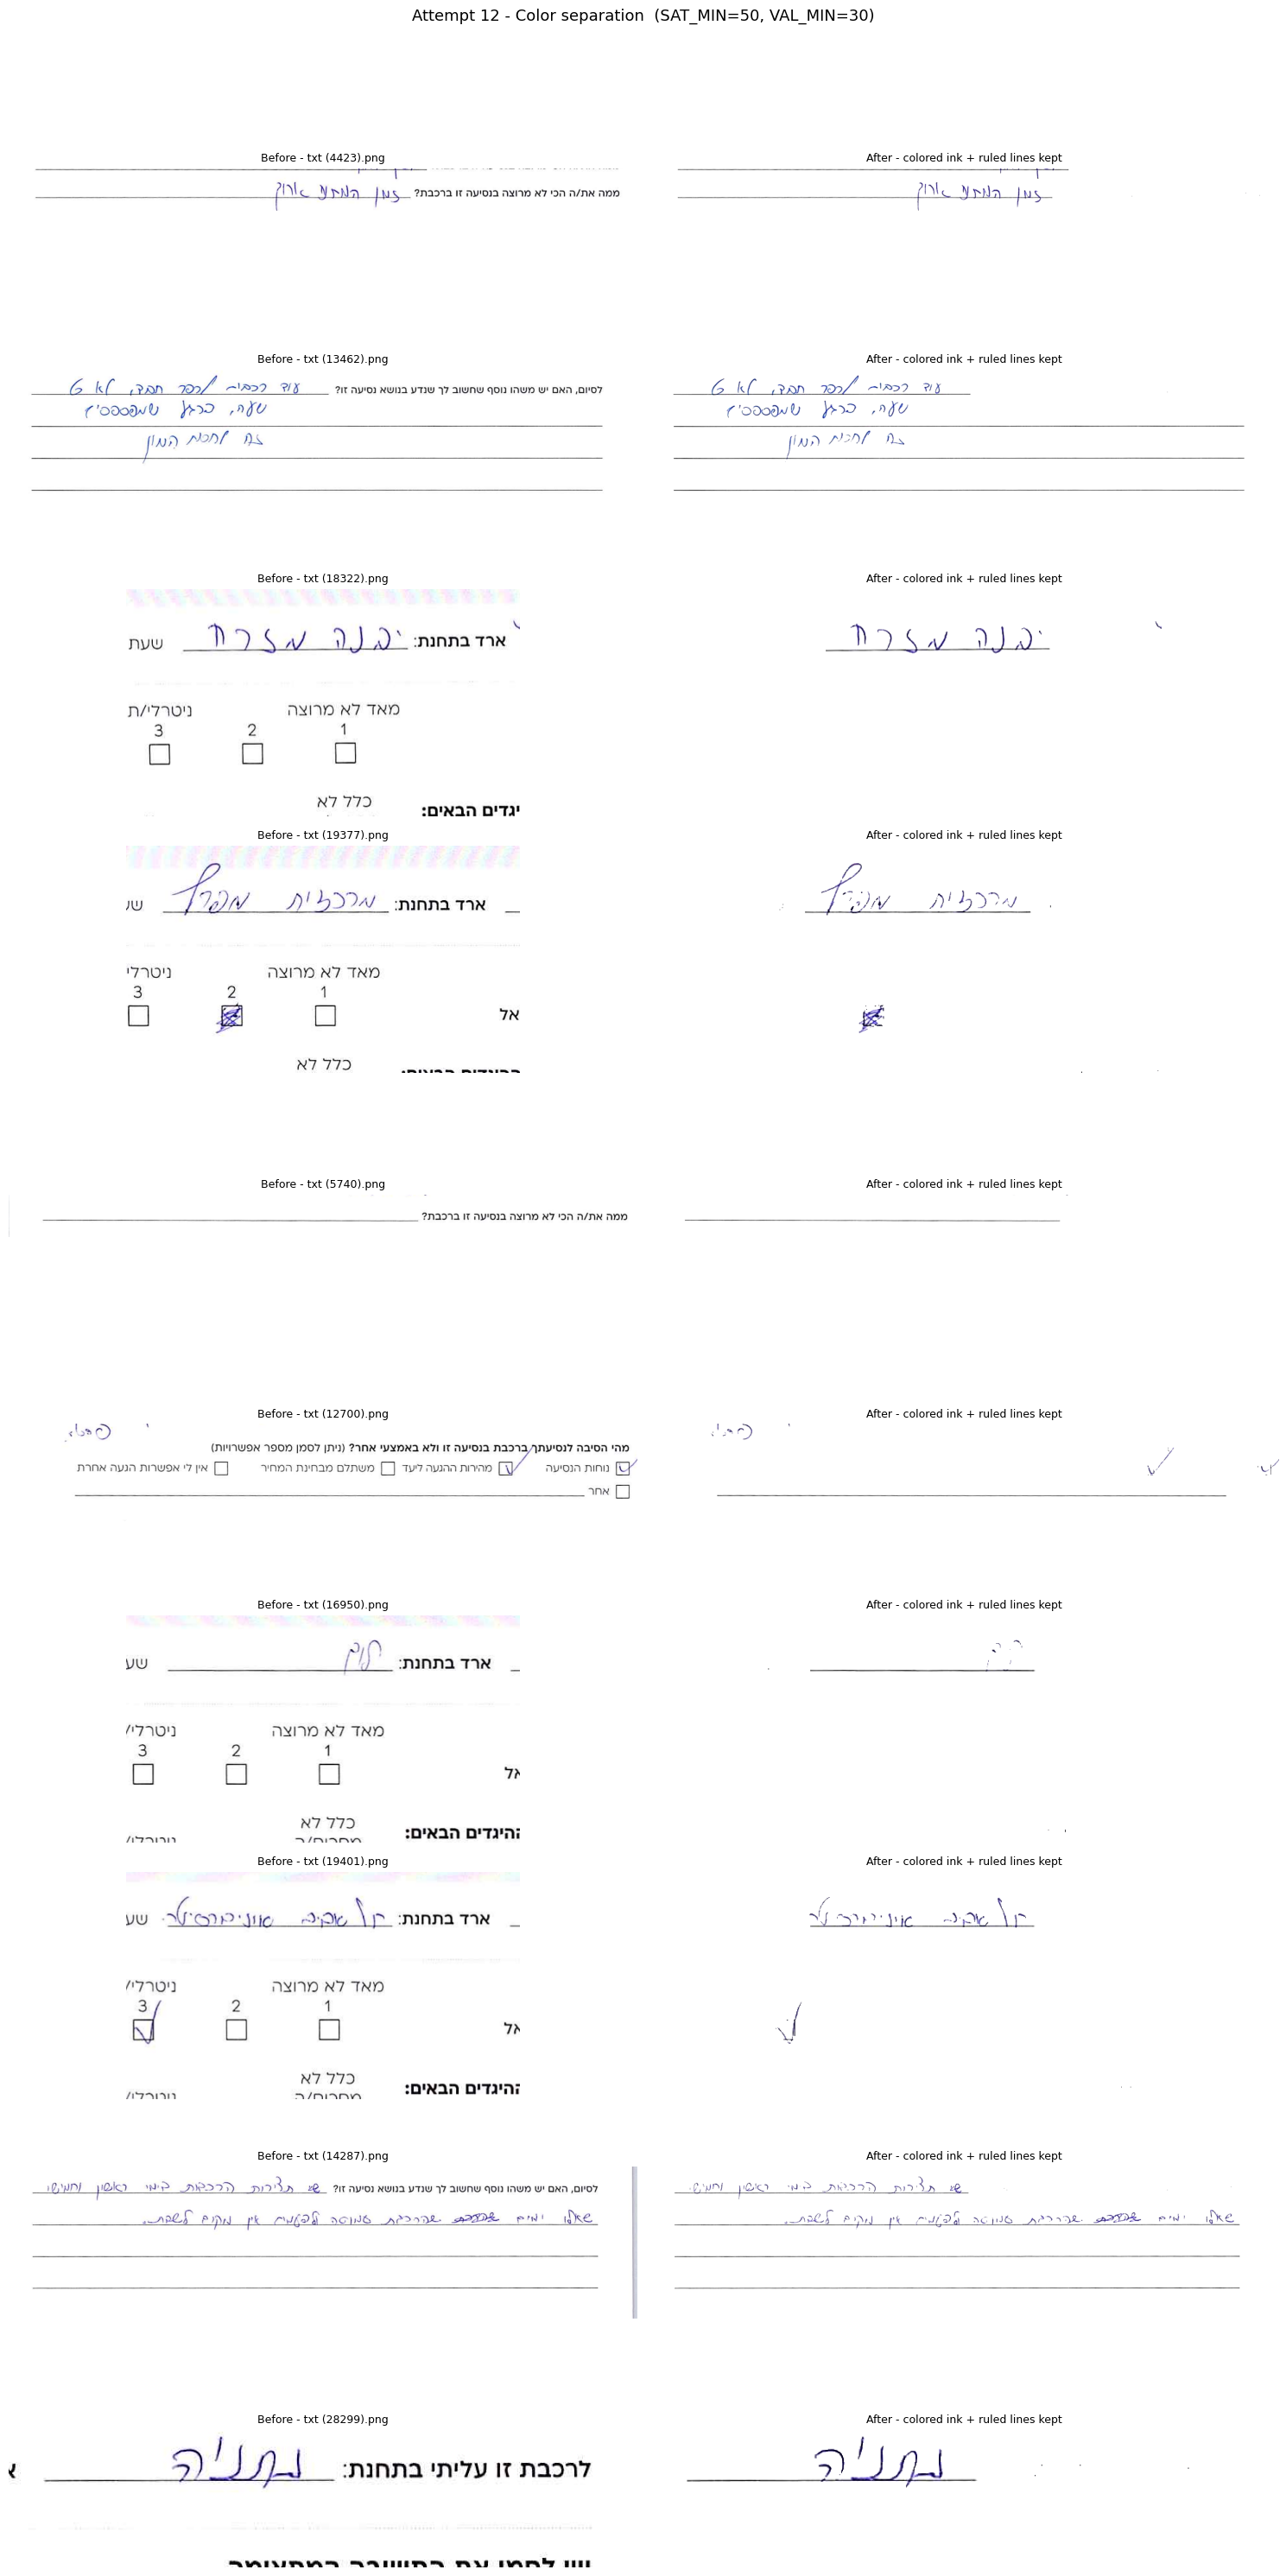

In [5]:
import os, cv2, random, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

A12_INPUT_FOLDER   = "dataPrinted"
A12_OUTPUT_FOLDER  = "handwritenOnly"
A12_SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}

# Tunables
A12_SAT_MIN      = 50    # min Saturation for colored ink; raise to cut printed-black leak
A12_VAL_MIN      = 30    # very dark pixels are almost always pure black ink
A12_LINE_MIN_LEN = 100   # min horizontal run (px) to count as a ruled line

a12_image_files = [f for f in os.listdir(A12_INPUT_FOLDER)
                   if Path(f).suffix.lower() in A12_SUPPORTED_EXTS]

def a12_detect_lines(img_gray, min_length=A12_LINE_MIN_LEN):
    _, binary = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel    = cv2.getStructuringElement(cv2.MORPH_RECT, (min_length, 1))
    lines     = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    vk        = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
    lines     = cv2.dilate(lines, vk, iterations=1)
    return lines > 0

def a12_process(img_bgr):
    # Separate colored ink from black/gray using HSV saturation.
    # Printed black text from scanner gets S~5-20 due to JPEG noise;
    # real colored ink sits at S>=50, so SAT_MIN=50 cleanly separates them.
    # VAL_MIN=30 excludes very-dark pixels with only slight saturation.
    # Morphological close fills tiny gaps inside strokes from compression.
    # Horizontal ruled lines are always restored at the end.
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    color_mask = (S >= A12_SAT_MIN) & (V >= A12_VAL_MIN)
    kernel     = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    color_mask = cv2.morphologyEx(color_mask.astype("uint8") * 255,
                                  cv2.MORPH_CLOSE, kernel, iterations=1) > 0
    result             = np.full_like(img_bgr, 255)
    result[color_mask] = img_bgr[color_mask]
    img_gray          = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    line_mask         = a12_detect_lines(img_gray)
    result[line_mask] = img_bgr[line_mask]
    return result

a12_preview = random.sample(a12_image_files, min(10, len(a12_image_files)))
fig, axes   = plt.subplots(len(a12_preview), 2, figsize=(15, 3 * len(a12_preview)))
if len(a12_preview) == 1:
    axes = [axes]
for i, fname in enumerate(a12_preview):
    img = cv2.imread(os.path.join(A12_INPUT_FOLDER, fname))
    if img is None:
        continue
    result = a12_process(img)
    axes[i][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i][0].set_title("Before - " + fname, fontsize=9)
    axes[i][0].axis("off")
    axes[i][1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[i][1].set_title("After - colored ink + ruled lines kept", fontsize=9)
    axes[i][1].axis("off")
plt.suptitle("Attempt 12 - Color separation  (SAT_MIN=%d, VAL_MIN=%d)" %
             (A12_SAT_MIN, A12_VAL_MIN), fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [6]:
# Attempt 12 - Batch: process all 28K images
# Requires the cell above to have been run first (defines a12_process, a12_image_files, etc.)

import os
from tqdm import tqdm

os.makedirs(A12_OUTPUT_FOLDER, exist_ok=True)

a12_errors = []
for fname in tqdm(a12_image_files, desc="Attempt 12 — batch"):
    img = cv2.imread(os.path.join(A12_INPUT_FOLDER, fname))
    if img is None:
        a12_errors.append(fname)
        continue
    result = a12_process(img)
    cv2.imwrite(os.path.join(A12_OUTPUT_FOLDER, fname), result)

print(f"Done. {len(a12_image_files) - len(a12_errors)}/{len(a12_image_files)} saved to '{A12_OUTPUT_FOLDER}'.")
if a12_errors:
    print(f"Failed to read {len(a12_errors)} files:", a12_errors[:10])


Attempt 12 — batch: 100%|██████████| 28203/28203 [06:35<00:00, 71.37it/s] 

Done. 28203/28203 saved to 'handwritenOnly'.
